# 🔬 Taller: Clasificación de eventos Cherenkov con CNN
## Super-Kamiokande × Inteligencia Artificial

---

## 🌊 ¿Dónde estamos parados?

En Japón, enterrado a **1,000 metros bajo la montaña Ikeno**, existe uno de los detectores de física de partículas más extraordinarios del mundo: **Super-Kamiokande (Super-K)**.

Imagina un cilindro gigante de **50,000 toneladas de agua ultrapura** — tan pura que si metieras la mano no verías tu brazo a 30 cm de distancia. Las paredes están cubiertas por **13,000 sensores fotomultiplicadores**: enormes ojos de vidrio que detectan incluso un fotón individual.

Cuando una partícula subatómica cruza el agua **más rápido que la luz dentro del agua** (sí, eso es posible sin violar la relatividad), produce un destello de luz azulada llamado **radiación Cherenkov** — el equivalente óptico del *boom* sónico de un avión supersónico. Ese destello forma un **anillo** en las paredes del detector.

> 🔗 **Monitor en tiempo real de Super-Kamiokande:**  
> **[https://www-sk.icrr.u-tokyo.ac.jp/realtimemonitor/](https://www-sk.icrr.u-tokyo.ac.jp/realtimemonitor/)**  
> Ábrelo ahora mismo. Estás viendo partículas reales cruzando el detector en este instante.

---

## ⚛️ ¿Qué busca Super-Kamiokande?

El Gran Misterio: **¿Por qué el universo existe?**

Las ecuaciones de la física predicen que el Big Bang creó igual cantidad de materia y antimateria. Deberían haberse aniquilado mutuamente. Pero aquí estamos. Algo rompió ese equilibrio perfecto.

Los candidatos principales son los **neutrinos** — partículas casi sin masa que en este momento atraviesan tu cuerpo (y la Tierra entera) sin sentirlas. Para estudiar su comportamiento, el detector necesita distinguir qué tipo de partícula produjo cada evento:

| Clase | Partícula | ¿Cómo luce el anillo Cherenkov? |
|-------|-----------|----------------------------------|
| `mu_like` | Muón (µ) | **Borde nítido y continuo** — viaja en línea recta |
| `e_like` | Electrón / positrón | **Borde difuso o granulado** — crea una cascada de partículas |

Antes, físicos expertos revisaban miles de eventos manualmente. Hoy, una **red neuronal** lo hace en milisegundos y con precisión comparable a los expertos.

---

## 🤖 ¿Qué haremos hoy?

Entrenaremos una **Red Neuronal Convolucional (CNN)** — el mismo tipo de IA que usa tu celular para reconocer caras o un médico para detectar tumores — para clasificar automáticamente eventos de Super-K.

Al terminar habrás:
- ✅ Cargado y explorado imágenes reales del detector
- ✅ Construido y entrenado tu primera CNN desde cero
- ✅ Evaluado su rendimiento con métricas profesionales
- ✅ Tomado una captura del monitor en tiempo real y dejado que **tu modelo la clasifique**

---

## 🗺️ Mapa del taller

```
Sección 1 → Setup y librerías
Sección 2 → Verificar GPU
Sección 3 → Cargar dataset desde Drive
Sección 4 → Semilla aleatoria + preparar datos (70/15/15)
Sección 5 → Visualizar imágenes mu_like vs e_like
Sección 6 → Construir la CNN capa por capa
Sección 7 → Entrenar el modelo (20 épocas)
Sección 8 → ¿Qué "ve" la red? Filtros y activaciones
Sección 9 → Demo en vivo: clasificar imagen del monitor SK
Sección 10 → Guardar el modelo
```

> 💡 **Cómo ejecutar:** `Shift + Enter` en cada celda. No necesitas entender cada línea de código — enfócate en el concepto que explica el texto antes de cada bloque.


---
## 🛠️ Sección 1 — Preparar el entorno

### ¿Qué hace esta celda?

Antes de cocinar necesitas reunir ingredientes. Esta celda importa las **librerías** que usaremos:

| Librería | Para qué sirve |
|----------|----------------|
| **NumPy** | Matemáticas con arreglos de números (matrices, vectores) |
| **Matplotlib** | Graficar imágenes y curvas de entrenamiento |
| **scikit-learn** | Métricas de evaluación del modelo (exactitud, F1, matriz de confusión) |

También define funciones auxiliares para el caso en que scikit-learn tenga algún problema de compatibilidad.

> ✅ **Resultado esperado:** `PASO 1 listo. HAS_SKLEARN = True`


In [3]:
# PASO 1 — Setup sin instalaciones ni reinicios
# Prepara utilidades y un fallback puro NumPy por si scikit-learn falla.

import numpy as np
import matplotlib.pyplot as plt

# 1) Detección segura de scikit-learn (sin bloquear si hay binarios incompatibles)
HAS_SKLEARN = True
try:
    from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay, accuracy_score, precision_recall_fscore_support
except Exception as e:
    print("Aviso: scikit-learn no está usable. Usaré fallback con NumPy. Detalle:", str(e))
    HAS_SKLEARN = False

# 2) Helpers comunes (sirven tanto con sklearn como con fallback)
def _ensure_label_vectors(y_true, y_pred=None, y_proba=None):
    """
    Convierte a etiquetas 1D:
      - y_true: verdaderas
      - y_pred: predichas (opcional)
      - y_proba: probabilidades (opcional)
    Devuelve: (y_true_vec, y_pred_vec)
    """
    y_true = np.asarray(y_true)
    if y_pred is None and y_proba is None:
        raise ValueError("Debes proporcionar y_pred o y_proba.")
    if y_pred is None:
        y_proba = np.asarray(y_proba)
        if y_proba.ndim == 1:   # binario (prob de clase positiva)
            y_pred = (y_proba >= 0.5).astype(int)
        else:                    # multiclase
            y_pred = np.argmax(y_proba, axis=1)
    else:
        y_pred = np.asarray(y_pred)
    if y_true.shape[0] != y_pred.shape[0]:
        raise ValueError("y_true y y_pred deben tener la misma longitud.")
    return y_true, y_pred

# 3) Fallback puro NumPy para matriz de confusión y métricas
def confusion_matrix_numpy(y_true, y_pred, labels=None, normalize=None):
    if labels is None:
        labels = np.unique(np.concatenate([y_true, y_pred]))
    idx = {l:i for i,l in enumerate(labels)}
    cm = np.zeros((len(labels), len(labels)), dtype=np.int64)
    for t,p in zip(y_true, y_pred):
        cm[idx[t], idx[p]] += 1
    cmf = cm.astype(float)
    if normalize == "true":
        den = cm.sum(axis=1, keepdims=True).clip(min=1)
        cmf = cm / den
    elif normalize == "pred":
        den = cm.sum(axis=0, keepdims=True).clip(min=1)
        cmf = cm / den
    elif normalize == "all":
        den = cm.sum().clip(min=1)
        cmf = cm / den
    return cm, cmf, labels

def plot_confusion_matrix_numpy(cm_display, labels, title="Matriz de confusión"):
    fig, ax = plt.subplots()
    im = ax.imshow(cm_display, interpolation="nearest")
    ax.set_title(title)
    ax.set_xlabel("Predicción")
    ax.set_ylabel("Verdadero")
    ax.set_xticks(range(len(labels))); ax.set_yticks(range(len(labels)))
    ax.set_xticklabels(labels, rotation=45, ha="right"); ax.set_yticklabels(labels)
    for i in range(cm_display.shape[0]):
        for j in range(cm_display.shape[1]):
            v = cm_display[i, j]
            ax.text(j, i, f"{v:.2f}" if cm_display.dtype.kind=='f' else f"{v}",
                    ha="center", va="center")
    plt.colorbar(im, ax=ax)
    plt.tight_layout(); plt.show()

def metrics_numpy(y_true, y_pred):
    acc = (y_true == y_pred).mean()
    labels = np.unique(y_true)
    precs, recs, f1s = [], [], []
    for l in labels:
        tp = ((y_true == l) & (y_pred == l)).sum()
        fp = ((y_true != l) & (y_pred == l)).sum()
        fn = ((y_true == l) & (y_pred != l)).sum()
        prec = tp / (tp + fp) if (tp + fp) > 0 else 0.0
        rec  = tp / (tp + fn) if (tp + fn) > 0 else 0.0
        f1   = 2*prec*rec/(prec+rec) if (prec+rec) > 0 else 0.0
        precs.append(prec); recs.append(rec); f1s.append(f1)
    return acc, float(np.mean(precs)), float(np.mean(recs)), float(np.mean(f1s))

print("PASO 1 listo. HAS_SKLEARN =", HAS_SKLEARN)



PASO 1 listo. HAS_SKLEARN = True


---
## ⚡ Sección 2 — Verificar GPU

### ¿Por qué necesitamos una GPU?

Una **CPU** (el procesador de tu laptop) ejecuta instrucciones de una en una, muy rápido. Una **GPU** (tarjeta gráfica) ejecuta miles de operaciones *al mismo tiempo* — exactamente lo que necesita una red neuronal, que implica millones de multiplicaciones de matrices en cada paso.

**Entrenamiento de esta CNN:**
- En CPU → ~30 minutos
- En GPU T4 de Colab → **~1-2 minutos** ✨

**Antes de ejecutar esta celda:**  
`Entorno de ejecución` → `Cambiar tipo de entorno de ejecución` → selecciona **GPU (T4)**

> ✅ **Resultado esperado:** Debe aparecer al menos un `PhysicalDevice` de tipo GPU en la lista.


In [4]:
import tensorflow as tf
print("TensorFlow:", tf.__version__)
print("GPU disponible:", tf.config.list_physical_devices('GPU'))

TensorFlow: 2.19.0
GPU disponible: [PhysicalDevice(name='/physical_device:GPU:0', device_type='GPU')]


In [5]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


---
## 📦 Sección 3 — Montar Google Drive y cargar el dataset

### ¿Qué es un dataset en visión por computadora?

Un **dataset** es una colección de ejemplos etiquetados — el "libro de texto" que estudia la red neuronal. El nuestro contiene imágenes en escala de grises de eventos Cherenkov del detector Super-K, organizadas así:

```
SK_mu_e_dataset_v01/
  train/     ← 70% de imágenes  →  la red APRENDE aquí
    mu_like/
    e_like/
  val/       ← 15% de imágenes  →  ajustamos parámetros mientras entrenamos
    mu_like/
    e_like/
  test/      ← 15% de imágenes  →  evaluación FINAL (la red jamás las vio)
    mu_like/
    e_like/
```

**Analogía:** Es como estudiar para un examen con ejercicios de práctica (train), hacer simulacros (val) y finalmente presentar el examen real con preguntas nuevas (test).

**Antes de ejecutar:** Sube `SK_mu_e_dataset_v01.zip` a la carpeta `colab_shared` de tu Google Drive.

> ✅ **Resultado esperado:** Se imprimen las rutas de las 6 carpetas (train/val/test × mu_like/e_like).


In [6]:

from google.colab import drive
drive.mount('/content/drive')

ZIP_PATH = '/content/drive/MyDrive/colab_shared/SK_mu_e_dataset_v01.zip'  # <-- ajusta si es necesario
DATA_DIR = '/content/dataset'  # carpeta destino
import os, zipfile, sys

os.makedirs(DATA_DIR, exist_ok=True)
with zipfile.ZipFile(ZIP_PATH, 'r') as zf:
    zf.extractall(DATA_DIR)

# Mostrar árbol para verificar
!find /content/dataset -maxdepth 3 -type d -print


Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
/content/dataset
/content/dataset/val
/content/dataset/val/e_like
/content/dataset/val/mu_like
/content/dataset/test
/content/dataset/test/e_like
/content/dataset/test/mu_like
/content/dataset/train
/content/dataset/train/e_like
/content/dataset/train/mu_like


---
## 🎲 Sección 4 — Semilla aleatoria y carga de datos (70 / 15 / 15)

### ¿Por qué fijamos una semilla?

El entrenamiento de redes neuronales usa muchos números aleatorios: inicialización de pesos, orden de imágenes, dropout, etc. Sin una semilla fija, cada ejecución daría resultados diferentes y sería imposible reproducirlos.

`SEED = 42` garantiza que tu entrenamiento sea **reproducible** — misma semilla, mismos resultados. Es práctica estándar en ciencia de datos e investigación.

### ¿Qué hace `image_dataset_from_directory`?

Keras lee las imágenes automáticamente desde la estructura de carpetas, las redimensiona a **224×224 píxeles**, las convierte a escala de grises y las agrupa en **lotes (batches) de 16** para ser eficiente en memoria durante el entrenamiento.

> ✅ **Resultado esperado:** Contador de imágenes por split (train / val / test).


In [7]:
SEED = 42
import os, random, numpy as np, tensorflow as tf
os.environ['PYTHONHASHSEED'] = str(SEED)
random.seed(SEED); np.random.seed(SEED); tf.random.set_seed(SEED)

IMG_SIZE = (224, 224)
BATCH_SIZE = 16

# Detectar automáticamente dónde están train/val/test
def find_base_dir(root="/content/dataset"):
    # 1) Caso típico: root/dataset/train|val|test
    if all(os.path.isdir(os.path.join(root, "dataset", d)) for d in ["train","val","test"]):
        return os.path.join(root, "dataset")
    # 2) Caso: root/train|val|test directamente
    if all(os.path.isdir(os.path.join(root, d)) for d in ["train","val","test"]):
        return root
    # 3) Buscar en subcarpetas
    for current, dirs, files in os.walk(root):
        if all(os.path.isdir(os.path.join(current, d)) for d in ["train","val","test"]):
            return current
    raise FileNotFoundError("No encuentro carpetas train/val/test dentro de /content/dataset")

BASE_DIR = find_base_dir("/content/dataset")
print("BASE_DIR detectado:", BASE_DIR)

train_dir = os.path.join(BASE_DIR, 'train')
val_dir   = os.path.join(BASE_DIR, 'val')
test_dir  = os.path.join(BASE_DIR, 'test')

train_ds = tf.keras.preprocessing.image_dataset_from_directory(
    train_dir, labels='inferred', label_mode='binary',
    color_mode='grayscale', batch_size=BATCH_SIZE,
    image_size=IMG_SIZE, shuffle=True, seed=SEED
)
val_ds = tf.keras.preprocessing.image_dataset_from_directory(
    val_dir, labels='inferred', label_mode='binary',
    color_mode='grayscale', batch_size=BATCH_SIZE,
    image_size=IMG_SIZE, shuffle=False
)
test_ds = tf.keras.preprocessing.image_dataset_from_directory(
    test_dir, labels='inferred', label_mode='binary',
    color_mode='grayscale', batch_size=BATCH_SIZE,
    image_size=IMG_SIZE, shuffle=False
)

print("Clases:", train_ds.class_names)

# Normalización y prefetch
norm = tf.keras.layers.Rescaling(1./255)
AUTOTUNE = tf.data.AUTOTUNE
train_ds = train_ds.map(lambda x,y: (norm(x), y)).prefetch(AUTOTUNE)
val_ds   = val_ds.map(lambda x,y: (norm(x), y)).prefetch(AUTOTUNE)
test_ds  = test_ds.map(lambda x,y: (norm(x), y)).prefetch(AUTOTUNE)


BASE_DIR detectado: /content/dataset
Found 12 files belonging to 2 classes.
Found 2 files belonging to 2 classes.
Found 3 files belonging to 2 classes.
Clases: ['e_like', 'mu_like']


---
## 👁️ Sección 5 — Exploración visual del dataset

### La regla de oro del Machine Learning: siempre mira tus datos

Antes de entrenar cualquier modelo debes ver qué hay en el dataset. Las preguntas que un científico de datos se hace aquí son:

- ¿Puedo distinguir las dos clases a simple vista?
- ¿Qué tan diferentes lucen `mu_like` y `e_like`?
- ¿Las imágenes tienen buena calidad o hay ruido?

### Lo que verás:

| `mu_like` (muón) | `e_like` (electrón/positrón) |
|-----------------|-----------------------------|
| Anillo con contorno **nítido y continuo** | Anillo con contorno **difuso o granulado** |
| El muón viaja recto → luz concentrada en un círculo limpio | El electrón choca y rebota → luz dispersa en cascada |

> 🤔 **Pausa para pensar:** ¿Cuánto tiempo tardarías tú en revisar 10,000 imágenes manualmente? Un físico experto tarda varios segundos por imagen. La red lo hará en milisegundos — y con consistencia perfecta, sin cansarse.


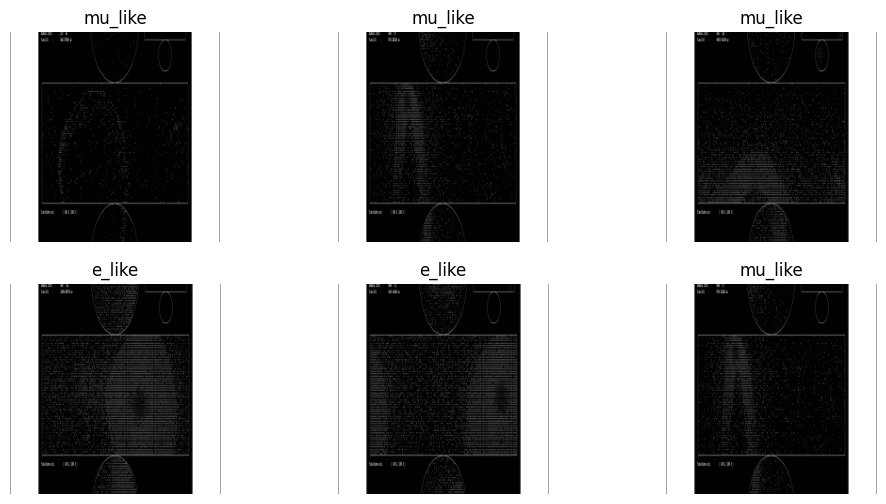

In [8]:

import matplotlib.pyplot as plt

def show_batch(dataset, n=6):
    images, labels = next(iter(dataset))
    n = min(n, images.shape[0])
    plt.figure(figsize=(12, 6))
    for i in range(n):
        ax = plt.subplot(2, (n+1)//2, i+1)
        plt.imshow(tf.squeeze(images[i]), cmap='gray')
        lab = 'mu_like' if labels[i].numpy().item() == 1.0 else 'e_like'
        plt.title(lab)
        plt.axis("off")
    plt.show()

show_batch(train_ds, n=6)


---
## 🧠 Sección 6 — Arquitectura de la CNN

### ¿Por qué una CNN y no una red neuronal normal?

Una red neuronal clásica vería tu imagen como una lista enorme de píxeles sin orden — perdería toda la información de *qué está junto a qué*. Las **Redes Neuronales Convolucionales (CNN)** fueron diseñadas específicamente para imágenes porque respetan su estructura espacial.

### Las piezas de nuestra CNN:

#### 🔍 `Conv2D` — Detector de patrones
Desliza una ventanita de 3×3 píxeles por toda la imagen buscando un patrón específico (un borde, una curva, una textura). Eso es un **filtro**. La red aprende *automáticamente* qué patrones importan para distinguir µ de e.

- **Conv2D(32)** — Primera pasada: detecta bordes y texturas simples
- **Conv2D(64)** — Combina bordes → detecta formas
- **Conv2D(128)** — Combina formas → detecta estructuras complejas (¿anillo nítido o difuso?)

#### ↓ `MaxPooling2D` — Reducción de resolución
Después de cada convolución, la imagen se reduce a la mitad tomando el valor máximo de cada cuadro 2×2. Resultado: menos parámetros y mayor robustez ante pequeñas variaciones.

#### 📊 `Flatten` + `Dense` — Toma de decisión
Los mapas de características se aplanan a un vector y se conectan a neuronas clásicas que combinan toda la información para dar una respuesta final.

#### 🎲 `Dropout(0.5)` — Prevención de "memorización"
Durante el entrenamiento, el 50% de las neuronas se apagan al azar en cada paso. Esto obliga a la red a no depender de una sola neurona, evitando el **sobreajuste** (memorizar los datos en lugar de aprender patrones generales).

#### → `Sigmoid` — Probabilidad de salida
La última neurona produce un número entre 0 y 1:
- Cercano a **1** → la red predice `mu_like`
- Cercano a **0** → la red predice `e_like`

### Diagrama completo:
```
Entrada: 224 × 224 × 1 (imagen en gris)
        ↓
  Conv2D(32)  + ReLU  →  MaxPool  →  112 × 112 × 32
        ↓
  Conv2D(64)  + ReLU  →  MaxPool  →   56 ×  56 × 64
        ↓
  Conv2D(128) + ReLU  →  MaxPool  →   28 ×  28 × 128
        ↓
  Flatten  →  vector de 100,352 valores
        ↓
  Dense(128) + ReLU  →  Dropout(0.5)
        ↓
  Dense(1) + Sigmoid  →  p(mu_like) ∈ [0, 1]
```

> 🤔 **Pausa para pensar:** `model.summary()` mostrará el número total de parámetros (pesos) que la red debe aprender. ¿Cuántos crees que serán? ¿Te sorprende la magnitud?


In [9]:
from tensorflow.keras import layers, models

def build_cnn(input_shape=(224,224,1)):
    model = models.Sequential([
        layers.Input(shape=input_shape),
        layers.Conv2D(32, (3,3), activation='relu', padding='same'),
        layers.MaxPooling2D((2,2)),
        layers.Conv2D(64, (3,3), activation='relu', padding='same'),
        layers.MaxPooling2D((2,2)),
        layers.Conv2D(128, (3,3), activation='relu', padding='same'),
        layers.MaxPooling2D((2,2)),
        layers.Flatten(),
        layers.Dense(128, activation='relu'),
        layers.Dropout(0.5),
        layers.Dense(1, activation='sigmoid')
    ])
    return model

model = build_cnn(input_shape=(224,224,1))
model.summary()


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d (Conv2D)                 │ (None, 224, 224, 32)   │           320 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ (None, 112, 112, 32)   │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ (None, 112, 112, 64)   │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_1 (MaxPooling2D)  │ (None, 56, 56, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_2 (Conv2D)               │ (None, 56, 56, 128)    │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_2 (MaxPooling2D)  │ (None, 28, 28, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten (Flatten)               │ (None, 100352)         │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 128)            │    12,845,184 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 1)              │           129 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 12,937,985 (49.35 MB)

 Trainable params: 12,937,985 (49.35 MB)

 Non-trainable params: 0 (0.00 B)

---
## 🏋️ Sección 7 — Compilar y entrenar (20 épocas)

### ¿Cómo aprende una red neuronal?

El entrenamiento es un ciclo automático de **prueba, error y corrección**:

1. La red recibe una imagen y **predice** si es `mu_like` o `e_like`
2. Se mide el **error** entre la predicción y la respuesta correcta usando la **función de pérdida** (Binary Crossentropy)
3. El error se propaga hacia atrás por toda la red (**backpropagation**)
4. El **optimizador Adam** ajusta cada peso en la dirección que reduce el error
5. Se repite con la siguiente imagen → y así con todo el dataset

Una **época** = un recorrido completo por todas las imágenes de entrenamiento. Hacemos **20 épocas**.

### Glosario de los logs en pantalla:

| Columna | Significado | ¿Qué queremos? |
|---------|-------------|----------------|
| `loss` | Error en entrenamiento | Que **baje** |
| `accuracy` | % correcto en entrenamiento | Que **suba** |
| `val_loss` | Error en validación | Que también **baje** (si sube mientras `loss` baja → sobreajuste) |
| `val_accuracy` | % correcto en validación | El **indicador real** del aprendizaje |

> ⏱️ Con GPU T4 esto tarda aproximadamente 1-2 minutos.
>
> 👀 Observa cómo cambia `val_accuracy` con cada época — ese es el momento en que la red mejora su comprensión de los anillos Cherenkov.


In [10]:

from tensorflow.keras import optimizers, losses, metrics

model.compile(
    optimizer=optimizers.Adam(learning_rate=1e-3),
    loss=losses.BinaryCrossentropy(),
    metrics=['accuracy']
)

EPOCHS = 20
history = model.fit(train_ds, validation_data=val_ds, epochs=EPOCHS)


Epoch 1/20
1/1 ━━━━━━━━━━━━━━━━━━━━ 7s 7s/step - accuracy: 0.5833 - loss: 0.6959 - val_accuracy: 0.5000 - val_loss: 0.6702
Epoch 2/20
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 87ms/step - accuracy: 0.5833 - loss: 0.7458 - val_accuracy: 0.5000 - val_loss: 0.7370
Epoch 3/20
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 98ms/step - accuracy: 0.6667 - loss: 0.7273 - val_accuracy: 0.5000 - val_loss: 0.6548
Epoch 4/20
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 85ms/step - accuracy: 0.7500 - loss: 0.6386 - val_accuracy: 0.5000 - val_loss: 0.6441
Epoch 5/20
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 97ms/step - accuracy: 0.8333 - loss: 0.5592 - val_accuracy: 1.0000 - val_loss: 0.6119
Epoch 6/20
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 98ms/step - accuracy: 0.7500 - loss: 0.5211 - val_accuracy: 0.5000 - val_loss: 0.6020
Epoch 7/20
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 98ms/step - accuracy: 1.0000 - loss: 0.4093 - val_accuracy: 0.5000 - val_loss: 0.5724
Epoch 8/20
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 98ms/step - accuracy: 0.6667 - loss: 0.5654 - val_accuracy: 1.0000 - val_loss: 0.4123
Ep

### 📈 ¿Qué significan estas curvas?

Con el dataset que usamos (pequeño por diseño para que el taller sea rápido), las curvas pueden ser un poco ruidosas — eso es completamente normal.

En experimentos reales como Super-K, se usan **cientos de miles de imágenes** y los modelos tienen arquitecturas mucho más sofisticadas. Sin embargo, el principio es exactamente el mismo que acabas de ejecutar.

**¿Cómo detectar sobreajuste?**
- Si `accuracy` llega a 100% pero `val_accuracy` se estanca o baja → la red memorizó el dataset de entrenamiento
- Es como el estudiante que memoriza los ejercicios del libro pero reprueba el examen con preguntas nuevas
- Soluciones: más datos, más Dropout, regularización, data augmentation

> 🤔 **Reflexión:** ¿Siempre mejora el modelo si entrenamos más épocas? ¿Qué pasa si entrenamos 200 épocas con un dataset pequeño?


---
## 🔬 Sección 8 — ¿Qué "ve" la red? Filtros y activaciones

### Abriendo la caja negra

Una crítica frecuente a las redes neuronales es que son **cajas negras** — funcionan, pero no sabemos cómo. En física de partículas esto importa mucho: los científicos necesitan entender *por qué* el modelo toma cada decisión antes de confiarle resultados científicos.

La **visualización de filtros y activaciones** es una técnica de **IA Explicable (XAI)** que nos permite ver dentro de la red.

### ¿Qué verás?

**Filtros de la primera capa Conv2D:**  
Son los 32 "detectores de patrones" que la red aprendió. Muchos se especializan en bordes, cambios de brillo o texturas específicas — muy parecido a cómo funciona la corteza visual de los mamíferos.

**Mapas de activación:**  
Muestran qué regiones de una imagen *activan* cada filtro. Las zonas brillantes indican que el filtro detectó su patrón ahí. Puedes ver cómo la red "presta atención" al borde del anillo Cherenkov.

> 🤔 **Observa:** ¿Los mismos filtros se activan con igual intensidad en un evento `mu_like` y uno `e_like`? Esa diferencia es exactamente lo que permite a la red distinguirlos.


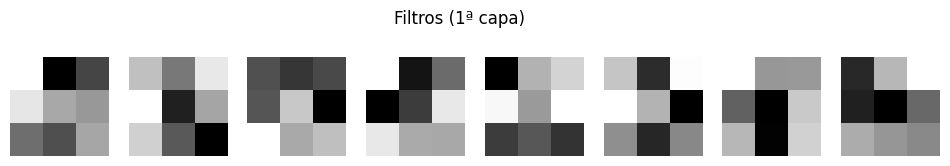

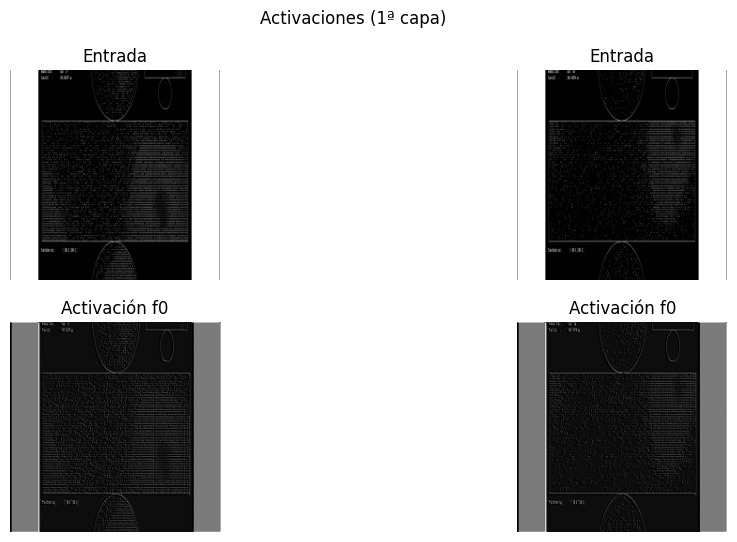

In [11]:
import matplotlib.pyplot as plt
import numpy as np
import tensorflow as tf

# Obtener primera capa conv
first_conv = None
for layer in model.layers:
    if isinstance(layer, tf.keras.layers.Conv2D):
        first_conv = layer
        break

if first_conv is None:
    raise RuntimeError("No encontré la primera capa Conv2D en el modelo.")

# Toma un batch de validación (si está vacío, intenta con train_ds)
try:
    images, labels = next(iter(val_ds))
except StopIteration:
    print("val_ds no tiene elementos; usando un batch de train_ds.")
    images, labels = next(iter(train_ds))

# n = cuántas muestras mostrar realmente (máx. 4 o el tamaño real del batch)
n = int(min(4, images.shape[0]))

# Mostrar pesos (filtros) de la 1ª capa
weights, biases = first_conv.get_weights()
w = (weights - weights.min()) / (weights.max() - weights.min() + 1e-9)
num_filters = min(8, w.shape[-1])
plt.figure(figsize=(12, 2))
for i in range(num_filters):
    ax = plt.subplot(1, num_filters, i+1)
    plt.imshow(w[:,:,0,i], cmap='gray')
    plt.axis('off')
plt.suptitle('Filtros (1ª capa)'); plt.show()

# Activaciones sobre n ejemplos
act_model = tf.keras.Model(inputs=model.inputs, outputs=first_conv.output)
acts = act_model.predict(images[:n], verbose=0)  # (n,H,W,filters)

plt.figure(figsize=(12, 6))
for i in range(n):  # solo hasta n
    ax = plt.subplot(2, n, i+1)
    plt.imshow(tf.squeeze(images[i]), cmap='gray')
    plt.title('Entrada'); plt.axis('off')
    ax = plt.subplot(2, n, i+1+n)
    fmap = acts[i, :, :, 0]
    plt.imshow(fmap, cmap='gray')
    plt.title('Activación f0'); plt.axis('off')
plt.suptitle('Activaciones (1ª capa)'); plt.show()



---
## 🚀 Sección 9 — Demo en tiempo real: clasifica un evento de Super-K

### ¡Ahora tú eres el detector!

Tu red neuronal está entrenada. Es momento de probarla con un evento **real** del detector Super-Kamiokande.

### Instrucciones paso a paso:

**1. Abre el monitor en tiempo real:**  
👉 [https://www-sk.icrr.u-tokyo.ac.jp/realtimemonitor/](https://www-sk.icrr.u-tokyo.ac.jp/realtimemonitor/)

**2. Identifica el "barrel" (panel central):**  
Es la franja horizontal del medio — las paredes cilíndricas del detector desenrolladas. Los anillos Cherenkov son más claros ahí.

**3. Toma una captura de pantalla** y recórtala dejando solo el panel barrel.

**4. Ejecuta la celda de abajo** y sube tu imagen cuando aparezca el botón.

**5. Lee la predicción:**
```
Predicción: MU-like | p(mu_like) = 0.91  →  la red está 91% segura de que es un muón
Predicción: E-like  | p(mu_like) = 0.08  →  la red está 92% segura de que es un electrón
```

> 🤔 **Para reflexionar después:** ¿La red acertó? ¿Cómo lo verificarías? ¿Qué pasaría si subieras una imagen que no sea del barrel, por ejemplo una foto de tu cara? ¿Qué dice eso sobre los límites de un modelo de IA?

> ⚠️ **Nota:** Asegúrate de haber ejecutado la Sección 7 (entrenamiento) antes de correr esta celda, o el modelo no estará disponible en memoria.


Saving SK1.png to SK1.png
Archivo recibido: SK1.png
Predicción: E-like | p(mu_like)=0.05


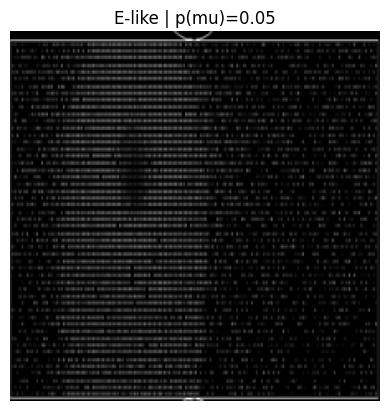

In [12]:
from google.colab import files
import numpy as np
import matplotlib.pyplot as plt
import os

# 1) Subir archivo (espera a que confirmes en el diálogo)
up = files.upload()
if not up:
    raise RuntimeError("No se subió ningún archivo. Vuelve a ejecutar y selecciona una imagen.")
FNAME = list(up.keys())[0]
print("Archivo recibido:", FNAME)

# 2) Lector tolerante: intenta con PIL y, si falla, usa OpenCV
def load_gray_224(path):
    from PIL import Image, UnidentifiedImageError
    try:
        img = Image.open(path).convert('L')   # a escala de grises
    except UnidentifiedImageError:
        import cv2
        arr = cv2.imread(path, cv2.IMREAD_GRAYSCALE)
        if arr is None:
            raise ValueError("No pude leer la imagen (formato no soportado). Usa PNG o JPG.")
        from PIL import Image
        img = Image.fromarray(arr)
    img = img.resize((224,224))
    arr = np.asarray(img).astype('float32')/255.0
    arr = np.expand_dims(arr, axis=(0, -1))  # (1, 224, 224, 1)
    return arr

# 3) Verificaciones y warm-up
assert 'model' in globals(), "El modelo no está en memoria. Ejecuta el entrenamiento (Sección 7) primero."
if not os.path.exists(FNAME):
    raise FileNotFoundError(f"No existe {FNAME}. Vuelve a subir el archivo.")

_ = model.predict(np.zeros((1,224,224,1), dtype='float32'), verbose=0)  # warm-up (inicializa GPU/cuDNN)

# 4) Cargar, predecir y mostrar
x = load_gray_224(FNAME)
prob_mu = float(model.predict(x, verbose=0)[0][0])
pred = "MU-like" if prob_mu > 0.5 else "E-like"
print(f"Predicción: {pred} | p(mu_like)={prob_mu:.2f}")

plt.imshow(x[0,:,:,0], cmap='gray')
plt.title(f"{pred} | p(mu)={prob_mu:.2f}")
plt.axis('off')
plt.show()


---
## 💾 Sección 10 — Guardar el modelo

### ¿Por qué guardar el modelo?

Entrenar una red neuronal toma tiempo y recursos computacionales. Una vez entrenada, podemos **guardar todos los pesos aprendidos** en un archivo `.keras` para:

- Volver a usarlo sin re-entrenar
- Compartirlo con otros investigadores
- Desplegarlo en una aplicación real
- Continuar entrenando desde donde lo dejamos (fine-tuning)

En Super-Kamiokande, los modelos entrenados se comparten entre todos los grupos de la colaboración internacional — equipos en Japón, Estados Unidos, Europa y México trabajan con los mismos modelos.

> ✅ **Resultado esperado:** El archivo `model_mu_e.keras` aparecerá en tu Google Drive.


In [13]:

SAVE_PATH = '/content/drive/MyDrive/colab_shared/model_mu_e.keras'  # ajusta si quieres
model.save(SAVE_PATH)
print("Modelo guardado en:", SAVE_PATH)


Modelo guardado en: /content/drive/MyDrive/colab_shared/model_mu_e.keras


---
## 🎓 ¿Qué aprendiste hoy?

En este taller pasaste por el ciclo completo de un proyecto de Machine Learning aplicado a física experimental:

| Paso | Concepto de ML | Conexión con Super-K |
|------|---------------|---------------------|
| Carga de datos | Dataset etiquetado | Imágenes reales del detector |
| Exploración visual | EDA (Análisis Exploratorio) | Ver la diferencia µ vs e |
| Arquitectura CNN | Visión por computadora | Detectar patrones en anillos Cherenkov |
| Entrenamiento | Backpropagation + Adam | La red aprende a distinguir partículas |
| Filtros y activaciones | IA Explicable (XAI) | Entender *por qué* clasifica así |
| Demo en tiempo real | Inferencia / deployment | Clasificar eventos reales del detector |

### ¿Qué sigue? — Próximos pasos si quieres ir más lejos

- **Más datos:** conseguir un dataset más grande mejora drásticamente el rendimiento
- **Data augmentation:** rotar, voltear y añadir ruido a las imágenes para que la red sea más robusta
- **Transfer learning:** usar una red pre-entrenada en millones de imágenes (ResNet, EfficientNet) y adaptarla a Super-K
- **Grad-CAM:** técnica avanzada de XAI que muestra exactamente qué píxeles influyen en la decisión
- **Clasificación multiclase:** añadir más tipos de partículas (piones, kaones, neutrinos atmosféricos)

---

> *"La física de partículas produce más datos de los que ningún humano podría analizar. La inteligencia artificial no reemplaza al físico — lo libera para hacer las preguntas que importan."*
